# Linear Regression

**Owner: Samith | Review 1 - Regression Track**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

SEED = 42
sns.set_theme(style="whitegrid", palette="colorblind")

data_path = next(
    (parent / "data" / "health_insurance.csv" for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

raw_df = pd.read_csv(data_path)
duplicate_count = int(raw_df.duplicated().sum())
df = raw_df.drop_duplicates().copy()
X = df.drop(columns="claim")
y = df["claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

X_train = X_train.copy()
X_test = X_test.copy()

# Age and BMI can interact in their effect on insurance cost.
for frame in (X_train, X_test):
    frame["age_bmi_interaction"] = frame["age"] * frame["bmi"]
numeric_features.append("age_bmi_interaction")

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]), categorical_features),
])

print(f"Removed {duplicate_count:,} exact duplicates.")
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

Removed 1,096 exact duplicates.
Training rows: 11,123; test rows: 2,781


In [2]:
from sklearn.linear_model import LinearRegression

model_name = "Linear Regression"
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
model.fit(X_train, y_train)

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.Series(
    model.named_steps["regressor"].coef_, index=feature_names
).sort_values(key=abs, ascending=False)
display(coefficients.head(10).to_frame("coefficient"))

,coefficient
numeric__smoker,19909.640290
categorical__hereditary_diseases_NoDisease,-11412.361025
numeric__age,5751.221384
categorical__hereditary_diseases_HeartDisease,4688.202056
categorical__hereditary_diseases_Arthritis,-2131.111226
categorical__job_title_Engineer,2114.898044
categorical__city_Warwick,2072.336159
categorical__job_title_Labourer,1826.894666
categorical__job_title_Politician,1812.520889
categorical__city_KanasCity,-1692.417687


,R2,RMSE,MAE
Linear Regression,0.762,5962.121,3929.924


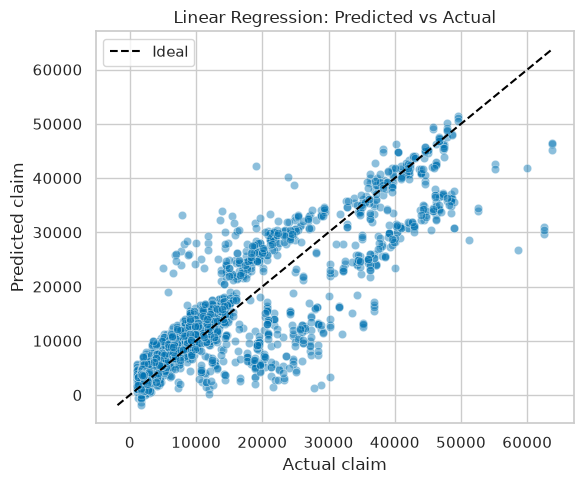

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
metrics = pd.DataFrame({
    "R2": [r2_score(y_test, y_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred))],
    "MAE": [mean_absolute_error(y_test, y_pred)],
}, index=[model_name])
display(metrics.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45, ax=ax)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, "--", color="black", label="Ideal")
ax.set(title=f"{model_name}: Predicted vs Actual", xlabel="Actual claim", ylabel="Predicted claim")
ax.legend()
plt.tight_layout()
plt.show()

assert np.isfinite(metrics.to_numpy()).all()

### Interpretation

The model uses the same deduplicated records, fixed 80:20 split, train-only imputation, robust scaling, encoding, and engineered feature as every other regression notebook. This makes the final metric comparison fair.

The coefficient table shows the strongest linear effects after scaling numerical features and one-hot encoding categories.